<a href="https://colab.research.google.com/github/frayyan-rgb/amazon-employee-feedback-analysis/blob/main/04_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install textblob

In [1]:
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("glassdoor_cleaned_text.csv")

In [4]:
df.head()

,review_id,rating_date,count_helpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,...,advice_to_management,review_pros,review_cons,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities,summary_cleaned,advice_to_management_cleaned,review_pros_cleaned,review_cons_cleaned
0,1,2025-06-03,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,don’t micro manage,not interactive \ncan leave or take off whenev...,inhumane \ndraining physically &amp; mentally,0.0,0.0,0.0,amazon,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally
1,2,2025-05-29,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,remove all attitude manager from warehouse,good and easy work enviorment,"sticks rules and completing targets any how, o...",5.0,3.0,5.0,good,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...
2,3,2025-05-28,0.0,1.0,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,NaN,"help to grow , good pay ,","limited opportunities for advancement,no clear...",5.0,5.0,5.0,good experience,NaN,help grow good pay,limited opportunities advancementno clear path...
3,4,2025-05-26,0.0,2.0,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,...,NaN,plenty of work\nmeet new people,tough on the body\nlabor intensive,2.0,2.0,3.0,dhdh,NaN,plenty work meet new people,tough body labor intensive
4,5,2025-05-23,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,NaN,good holiday pay \nadditional benefits for per...,not hiring permanent employees directly,0.0,0.0,0.0,good pay rate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly


In [5]:
text_cols = [
    'summary_cleaned',
    'advice_to_management_cleaned',
    'review_pros_cleaned',
    'review_cons_cleaned',
]

# NaN -> empty string, join the columns with spaces, then collapse extra spaces
df['cleaned_text'] = (
    df[text_cols]
    .fillna('')
    .agg(' '.join, axis=1)
    .str.split()
    .str.join(' ')
)

# Drop rows with no text at all
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print(df.shape)

(139, 27)


In [6]:
df.head()

,review_id,rating_date,count_helpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,...,review_pros,review_cons,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities,summary_cleaned,advice_to_management_cleaned,review_pros_cleaned,review_cons_cleaned,cleaned_text
0,1,2025-06-03,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,not interactive \ncan leave or take off whenev...,inhumane \ndraining physically &amp; mentally,0.0,0.0,0.0,amazon,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,amazon don’t micro manage interactive leave ta...
1,2,2025-05-29,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,good and easy work enviorment,"sticks rules and completing targets any how, o...",5.0,3.0,5.0,good,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,good remove attitude manager warehouse good ea...
2,3,2025-05-28,0.0,1.0,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,"help to grow , good pay ,","limited opportunities for advancement,no clear...",5.0,5.0,5.0,good experience,NaN,help grow good pay,limited opportunities advancementno clear path...,good experience help grow good pay limited opp...
3,4,2025-05-26,0.0,2.0,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,...,plenty of work\nmeet new people,tough on the body\nlabor intensive,2.0,2.0,3.0,dhdh,NaN,plenty work meet new people,tough body labor intensive,dhdh plenty work meet new people tough body la...
4,5,2025-05-23,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,good holiday pay \nadditional benefits for per...,not hiring permanent employees directly,0.0,0.0,0.0,good pay rate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,good pay rate good holiday pay additional bene...


In [7]:
df['sentiment_polarity'] = df['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment_subjectivity'] = df['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [8]:
df.head()

,review_id,rating_date,count_helpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,...,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities,summary_cleaned,advice_to_management_cleaned,review_pros_cleaned,review_cons_cleaned,cleaned_text,sentiment_polarity,sentiment_subjectivity
0,1,2025-06-03,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,0.0,0.0,0.0,amazon,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,amazon don’t micro manage interactive leave ta...,-0.123333,0.495238
1,2,2025-05-29,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,5.0,3.0,5.0,good,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,good remove attitude manager warehouse good ea...,0.611111,0.677778
2,3,2025-05-28,0.0,1.0,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,5.0,5.0,5.0,good experience,NaN,help grow good pay,limited opportunities advancementno clear path...,good experience help grow good pay limited opp...,0.357143,0.431548
3,4,2025-05-26,0.0,2.0,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,...,2.0,2.0,3.0,dhdh,NaN,plenty work meet new people,tough body labor intensive,dhdh plenty work meet new people tough body la...,-0.126263,0.643939
4,5,2025-05-23,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,0.0,0.0,0.0,good pay rate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,good pay rate good holiday pay additional bene...,0.500000,0.533333


In [9]:
def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_polarity'].apply(label_sentiment)

In [10]:
df.head()

,review_id,rating_date,count_helpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,...,rating_senior_leadership,rating_career_opportunities,summary_cleaned,advice_to_management_cleaned,review_pros_cleaned,review_cons_cleaned,cleaned_text,sentiment_polarity,sentiment_subjectivity,sentiment_label
0,1,2025-06-03,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,0.0,0.0,amazon,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,amazon don’t micro manage interactive leave ta...,-0.123333,0.495238,negative
1,2,2025-05-29,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,3.0,5.0,good,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,good remove attitude manager warehouse good ea...,0.611111,0.677778,positive
2,3,2025-05-28,0.0,1.0,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,...,5.0,5.0,good experience,NaN,help grow good pay,limited opportunities advancementno clear path...,good experience help grow good pay limited opp...,0.357143,0.431548,positive
3,4,2025-05-26,0.0,2.0,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,...,2.0,3.0,dhdh,NaN,plenty work meet new people,tough body labor intensive,dhdh plenty work meet new people tough body la...,-0.126263,0.643939,negative
4,5,2025-05-23,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,0.0,...,0.0,0.0,good pay rate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,good pay rate good holiday pay additional bene...,0.500000,0.533333,positive


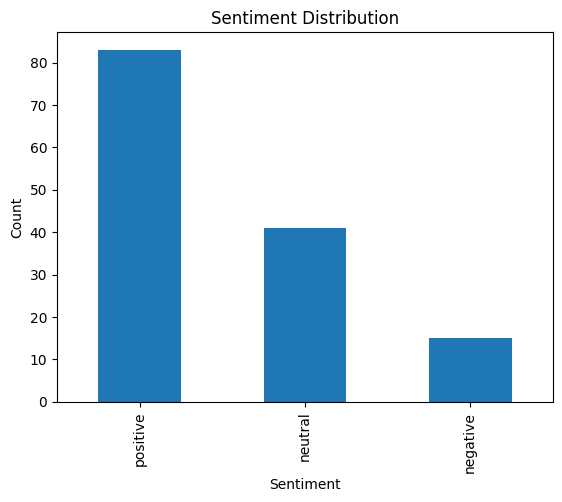

In [11]:
df['sentiment_label'].value_counts().plot(kind='bar', title="Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

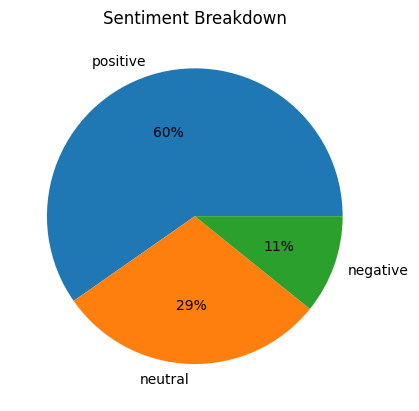

In [12]:
df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [15]:
youtube_df = pd.read_csv("youtube_cleaned_text.csv")

In [16]:
youtube_df.head()

,S No.,Link,Upload Date,Views,Likes,Comments,Transcript/Transcript Link,transcript_cleaned
0,2,https://www.youtube.com/watch?v=cGjy2bmpi5Q,Jan 2021,50K,1.1k,568,"""The reason why I quit is because it took way ...",reason quit took way much time started june 20...
1,3,https://www.youtube.com/watch?v=sHOWf2eotPc,August 2020,6.3k,197,6.3k,"""When I first started working at Amazon, I was...",first started working amazon night shift truth...
2,4,https://www.youtube.com/watch?v=U8h6DbdZ3bA,Oct 2017,478k,5k,2243,"""You're mostly working alone for 10 hours all ...",youre mostly working alone 10 hours night long...
3,5,https://www.youtube.com/watch?v=2kYeFclfugo,May 2020,114k,2.1k,755,"""The job is really, really repetitive, it's re...",job really really repetitive really mentally p...
4,6,https://www.youtube.com/watch?v=NwHYe4tszfI,Apr 2023,440,11,5,"""Night shifts also are good in a way to work, ...",night shifts also good way work especially sum...


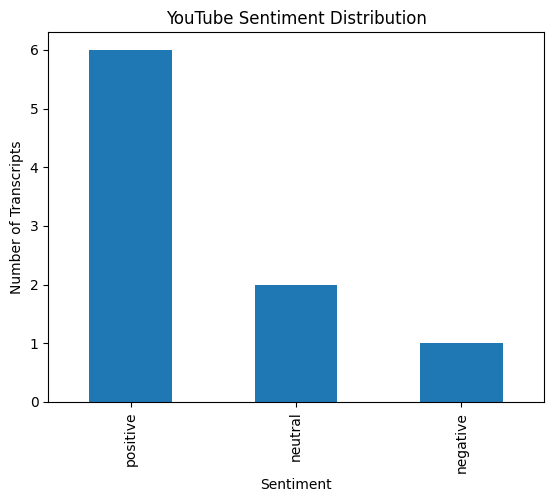

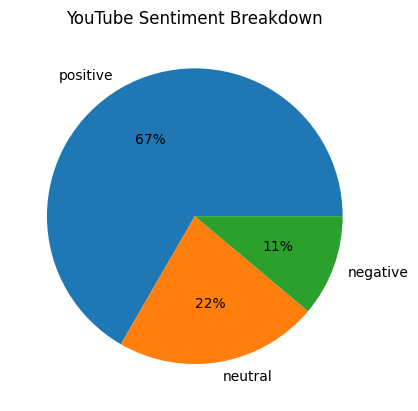

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'



youtube_df['sentiment_polarity'] = youtube_df['transcript_cleaned'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
youtube_df['sentiment_subjectivity'] = youtube_df['transcript_cleaned'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
youtube_df['sentiment_label'] = youtube_df['sentiment_polarity'].apply(label_sentiment)

youtube_df['sentiment_label'].value_counts().plot(kind='bar', title="YouTube Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Transcripts")
plt.show()

youtube_df['sentiment_label'].value_counts().plot(kind='pie', autopct='%1.0f%%', title="YouTube Sentiment Breakdown")
plt.ylabel('')
plt.show()

youtube_df.to_csv('youtube_sentiment.csv', index=False)